# 01 — Data Inspection

**Project:** Deep Learning for Multi-class Alzheimer's MRI Classification
**Day:** 1 of the project plan
**Goal:** before any training, look carefully at the dataset.

This notebook does only what is needed to *understand* the data:
1. Count images per class.
2. Show 4 random images per class so we know what an MRI slice looks like in each severity level.
3. Probe a sample of images to find out: are they grayscale or RGB? are sizes uniform? are any files corrupt?
4. Write down dataset limitations for the final report.

> **Important caveat (Day 1, Step 1.3 of the plan):**
> The Kaggle Alzheimer's MRI dataset is an *augmented and upsampled* benchmark.
> If we split at the image level, very similar images can leak across train / val / test
> and inflate our numbers. Treat all results as a benchmark comparison between
> architectures, not a clinical accuracy estimate. We repeat this in every notebook.


## 0. Environment setup

Works both locally and on Colab. On Colab, mount Drive and clone / copy the project there before running.

In [1]:
import os, sys
from pathlib import Path

# --- locate the project root so `from src...` works on either Colab or local Windows ---
def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py. Are you inside the project directory?")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\miaot\Github\Project_DeepLearningClass


In [2]:
# Detect Colab and (optionally) mount Drive. If you keep the dataset on Drive at
# /content/drive/MyDrive/Project_DeepLearningClass, this cell will pick it up.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB)


In Colab: False


In [3]:
from src.config import summary, set_global_seed, DATA_ROOT, REPORTS_DIR, FIGURES_DIR
print(summary())
set_global_seed()
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"DATA_ROOT not found: {DATA_ROOT}. On Colab, mount Drive and place the "
        f"dataset at <project>/archive/combined_images/<class>/."
    )


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42



## 1. Walk the data tree

List every JPG/PNG under each class folder. We do not load pixels yet — just paths.

In [4]:
from src.io_utils import list_images, get_logger
log = get_logger("01_inspection")
df = list_images(DATA_ROOT)
log.info("Found %d image files under %s", len(df), DATA_ROOT)
df.head()


[00:11:29] INFO Found 44000 image files under C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images


,filepath,class,label
0,C:\Users\miaot\Github\Project_DeepLearningClas...,NonDemented,0
1,C:\Users\miaot\Github\Project_DeepLearningClas...,NonDemented,0
2,C:\Users\miaot\Github\Project_DeepLearningClas...,NonDemented,0
3,C:\Users\miaot\Github\Project_DeepLearningClas...,NonDemented,0
4,C:\Users\miaot\Github\Project_DeepLearningClas...,NonDemented,0


## 2. Class counts

We expect approximately:
- NonDemented 12,800
- VeryMildDemented 11,200
- MildDemented 10,000
- ModerateDemented 10,000

The classes are imbalanced — NonDemented is ~28% larger than the smallest class.
When we report results we will look at macro F1 in addition to accuracy.

  NonDemented        12,800
  VeryMildDemented   11,200
  MildDemented       10,000
  ModerateDemented   10,000
  TOTAL              44,000
Saved: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\class_counts.png


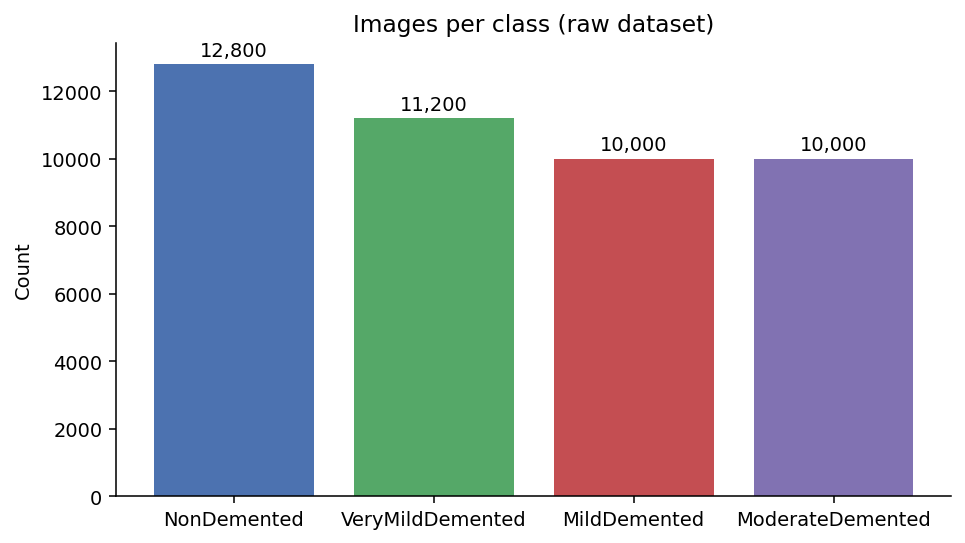

In [5]:
from src.inspection import class_counts
from src.plot_utils import plot_class_counts

counts = class_counts(df)
for k, v in counts.items():
    print(f"  {k:18s} {v:>6,}")
print(f"  {'TOTAL':18s} {sum(counts.values()):>6,}")

fig_path = plot_class_counts(counts, title="Images per class (raw dataset)")
print("Saved:", fig_path)
from IPython.display import Image as IPyImage
IPyImage(filename=str(fig_path))


## 3. Image probe — modes, sizes, corruption

We sample 50 images per class (200 total) and:
- record the PIL `mode` (RGB vs L grayscale),
- record the (width, height),
- run `Image.verify()` to flag corrupt files.

This is enough to decide our preprocessing without reading all 44k files twice.

In [6]:
from src.inspection import probe_images
probe = probe_images(df, n_per_class=50)
print("Checked:", probe["checked"])
print("Modes  :", probe["modes"])
print("Sizes  :", probe["sizes"])
print("Corrupt:", len(probe["corrupt"]))
if probe["corrupt"]:
    for line in probe["corrupt"][:5]:
        print(" ", line)


Checked:

 200
Modes  : {'RGB': 138, 'L': 62}
Sizes  : {'200x190': 140, '180x180': 24, '176x208': 36}
Corrupt: 0


### What we learn from the probe

* **Mode is mixed.** Some images come back as `RGB`, some as `L` (single-channel grayscale).
  → We will force every image to 3 channels in preprocessing so transfer-learning models
  (MobileNetV2, VGG16) work without per-image branching.
* **Sizes are not uniform.** We see 200×190, 180×180, and 176×208 in the sample.
  → We will resize to a single target (128×128) at load time.
* **No corrupt files** in the sampled subset. We will still wrap full-dataset reads in
  try/except later in case a few in the long tail are bad.


## 4. Visual sample grid

8 random images per class — the plan asks for 8-12. Sanity-check that labels look right and notice obvious quality differences between classes.

Saved: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\01_sample_grid.png


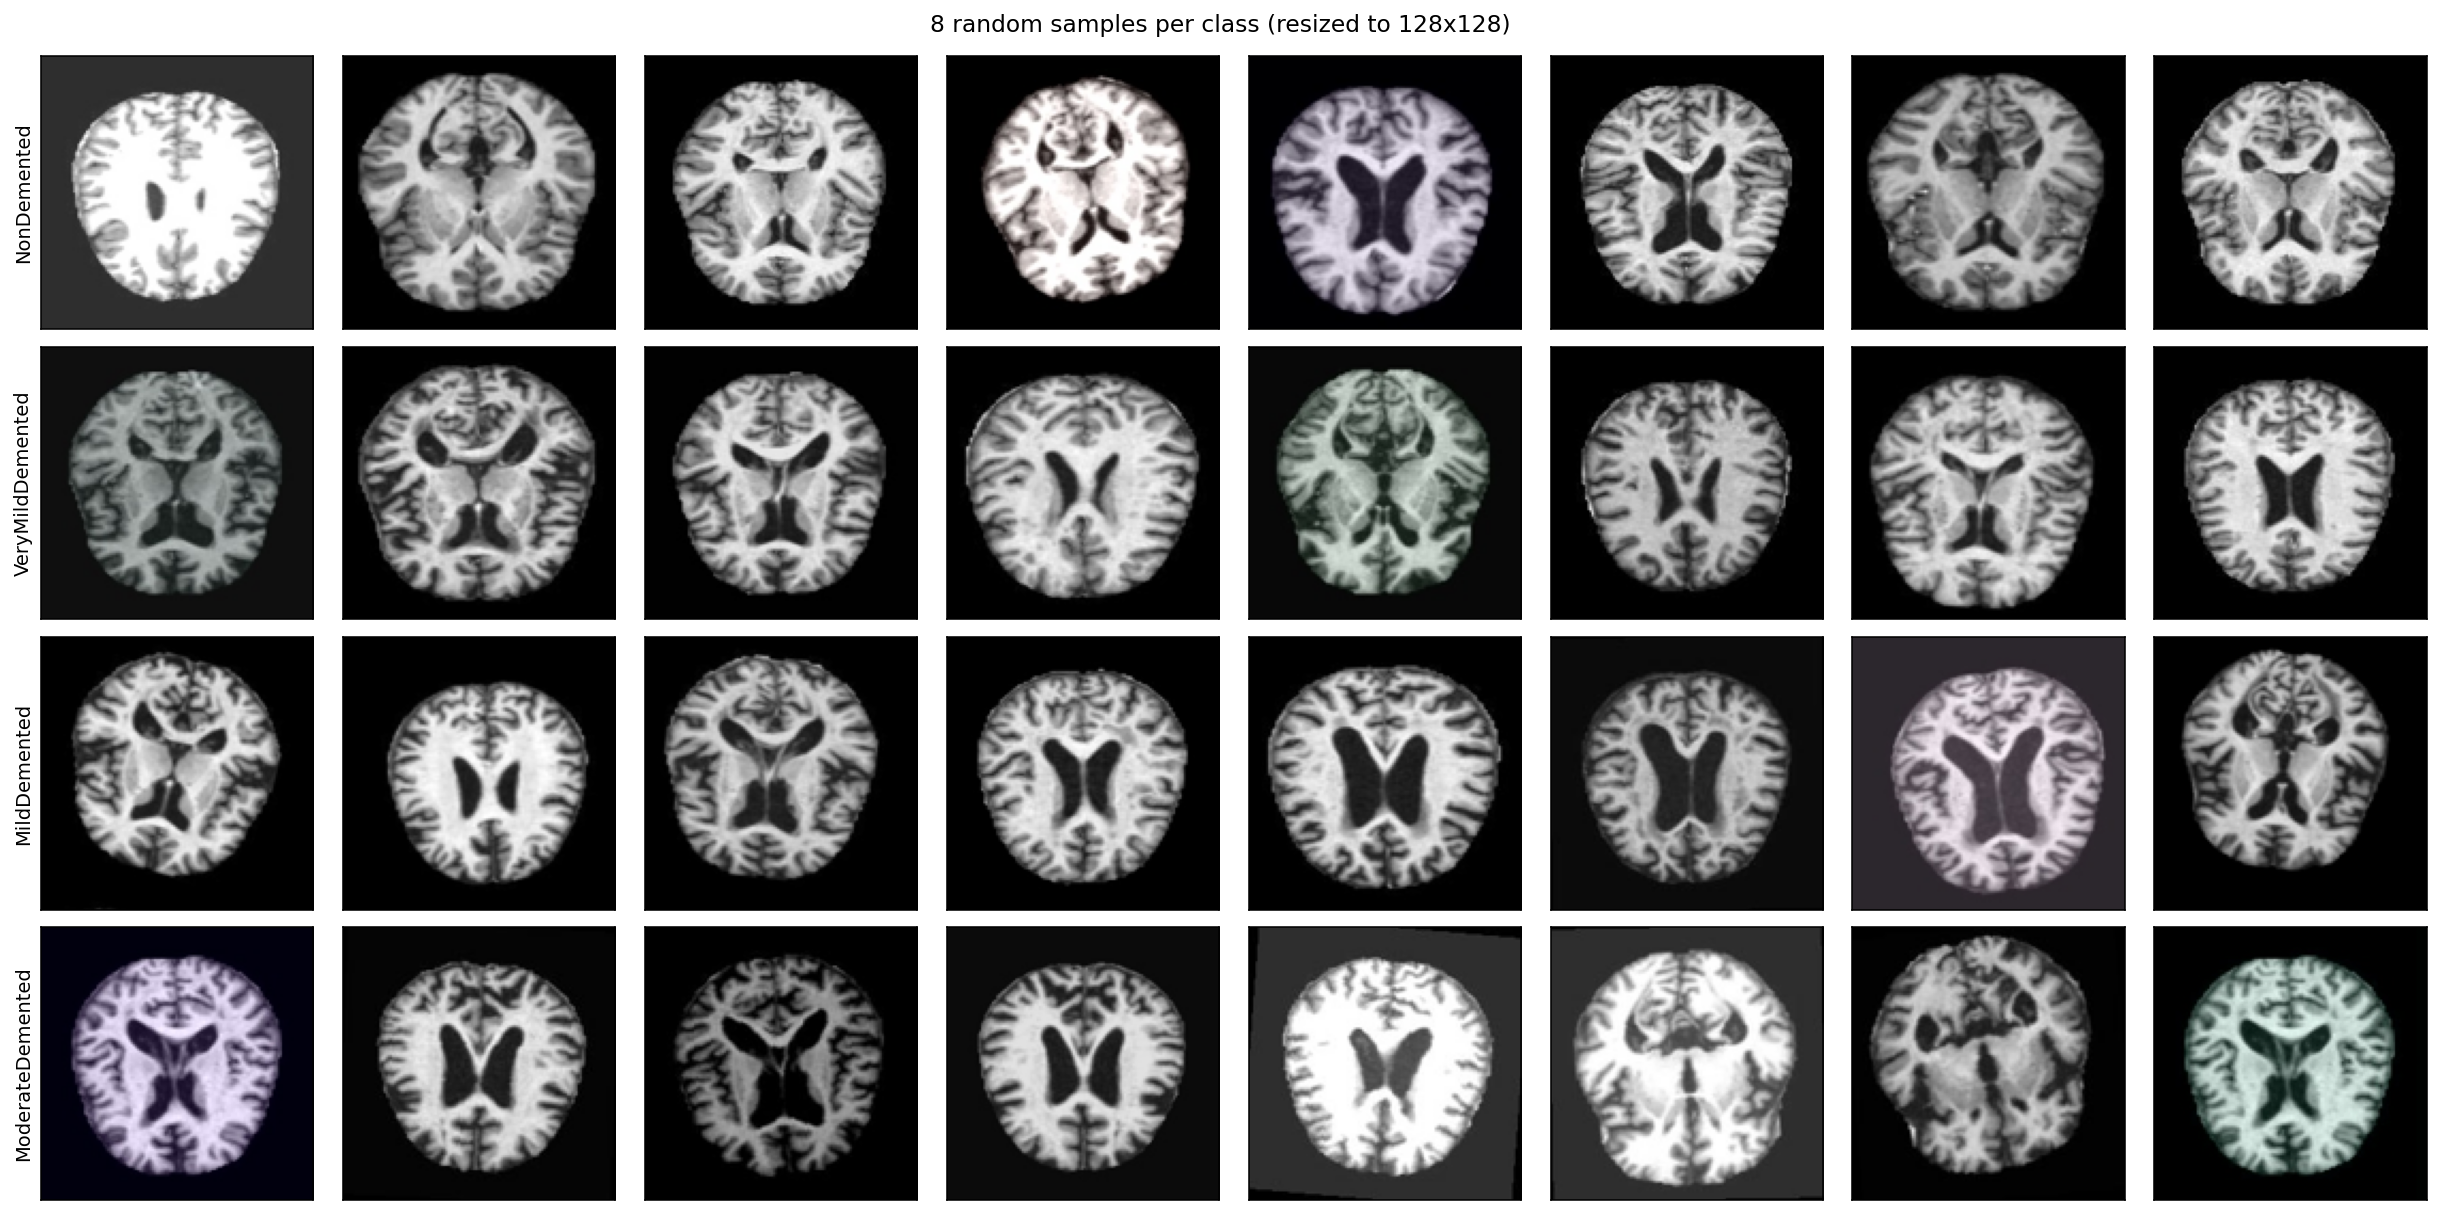

In [7]:
from src.inspection import sample_grid
grid_path = sample_grid(df, n_per_class=8)
print("Saved:", grid_path)
IPyImage(filename=str(grid_path))


## 5. Write the machine-readable summary

The `06_model_comparison` notebook and the final report load this JSON when describing the dataset, so it must always be in sync with the data root.

In [8]:
from src.inspection import run_inspection
summary_dict = run_inspection()
import json
print(json.dumps(summary_dict, indent=2))


[00:11:31] INFO Walking data tree at C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images


[00:11:31] INFO Found 44000 image files total


[00:11:31] INFO Saved class counts figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\class_counts.png


[00:11:31] INFO Probing image modes / sizes (sampled)


[00:11:31] INFO Modes seen: {'RGB': 138, 'L': 62}


[00:11:31] INFO Sizes seen: {'200x190': 140, '180x180': 24, '176x208': 36}


[00:11:31] INFO No corrupt images found in the sampled set


[00:11:31] INFO Saved sample grid: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\01_sample_grid.png


[00:11:31] INFO Wrote machine-readable summary: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\reports\01_data_inspection_summary.json


{
  "data_root": "C:\\Users\\miaot\\Github\\Project_DeepLearningClass\\archive\\combined_images",
  "total_images": 44000,
  "class_counts": {
    "NonDemented": 12800,
    "VeryMildDemented": 11200,
    "MildDemented": 10000,
    "ModerateDemented": 10000
  },
  "image_probe": {
    "checked": 200,
    "modes": {
      "RGB": 138,
      "L": 62
    },
    "sizes": {
      "200x190": 140,
      "180x180": 24,
      "176x208": 36
    },
    "corrupt": []
  },
  "figures": {
    "class_counts": "C:\\Users\\miaot\\Github\\Project_DeepLearningClass\\outputs\\figures\\class_counts.png",
    "sample_grid": "C:\\Users\\miaot\\Github\\Project_DeepLearningClass\\outputs\\figures\\01_sample_grid.png"
  },
  "elapsed_seconds": 0.8
}


## 6. Conclusions for Day 1

| Finding | Decision for the rest of the project |
|---|---|
| 44,000 images across 4 classes (matches the plan) | Proceed with all four classes. |
| Imbalance: NonDemented ≈ 1.28× ModerateDemented | Track macro F1 alongside accuracy. |
| Mixed RGB / grayscale | Force 3 channels everywhere in preprocessing. |
| Sizes 200×190 / 180×180 / 176×208 | Resize all to 128×128 (Day 2). |
| No corrupt files in sample | Continue, but defensively skip on read errors. |
| Augmented & upsampled benchmark | Repeat the limitation in every notebook + final report. |

Next: **02_data_preprocessing.ipynb** — stratified 70 / 15 / 15 split, light augmentation, save splits as CSVs.
